# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `<prénom>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [3]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../../mistral-tarif-v1/models/mistral_tarif_v1.joblib")
model_v1


LinearRegression()

Exécution en local du V1 :
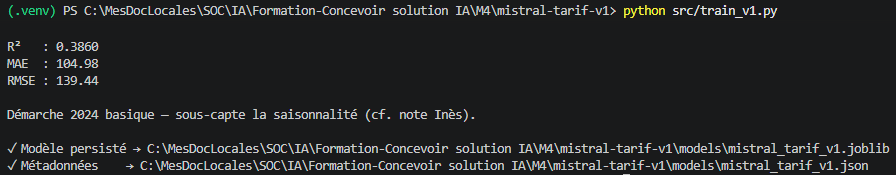

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [4]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


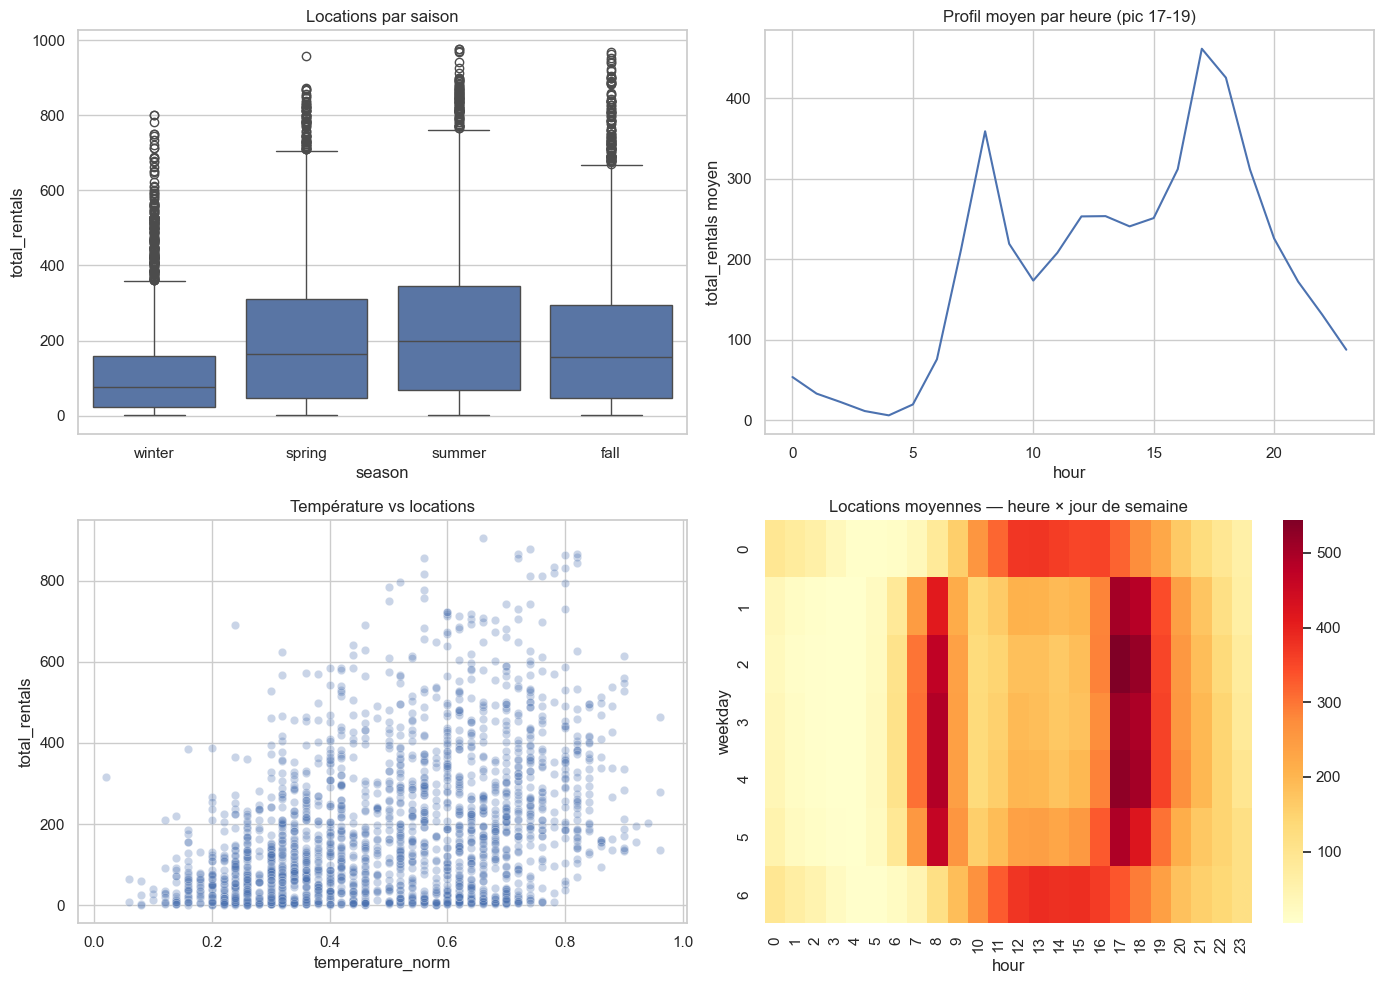

In [5]:
# 4 visualisations EDA
# (boxplot par saison, courbe par heure-moyenne, scatter temp vs cnt, heatmap corrélations)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution cible par saison
sns.boxplot(data=df, x="season", y="total_rentals",
            order=["winter", "spring", "summer", "fall"], ax=axes[0, 0])
axes[0, 0].set_title("Locations par saison")

# 2. Profil moyen par heure
df.groupby("hour")["total_rentals"].mean().plot(ax=axes[0, 1])
axes[0, 1].set_title("Profil moyen par heure (pic 17-19)")
axes[0, 1].set_ylabel("total_rentals moyen")

# 3. Scatter température vs cnt
sns.scatterplot(data=df.sample(2000), x="temperature_norm", y="total_rentals",
                alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Température vs locations")

# 4. Heatmap heure × weekday
pivot = df.pivot_table(values="total_rentals", index="weekday",
                       columns="hour", aggfunc="mean")
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("Locations moyennes — heure × jour de semaine")

plt.tight_layout()
plt.show()

## Analyse des graphiques

1. On remarque sur le graphique `Profil moyen par heure (pic 17-19)`, deux pics :
- le matin vers 8h
- le soir entre 17 et 18h

Surement dû aux personnes qui louent un vélo pour aller ou rentrer du travail


2. Grace au graphique `Locations moyennes — heure × jour de semaine` on remarque que les pic horaires listés au dessus ne sont valable que les jours de la semaine ce qui conforte l'idée de la location pour la travail.


3. Deux features que cette saisonnalité donne envie de créer (IA) :
- `is_rush_hour` (booléen) :
Les pics identifiés (8h le matin, 17-18h le soir) uniquement en semaine :
```python
df["is_rush_hour"] = (
    (df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)
).astype(int)
```
Capture directement le comportement "trajet domicile-travail" qui explique les deux pics — information que la baseline linéaire ne pouvait pas modéliser sans ça.

- `hour_sin` / `hour_cos` (encodage cyclique) :
L'heure est cyclique (23h est proche de 0h) — un encodage linéaire briserait cette continuité :
```python
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
```
Permet aux modèles linéaires de mesurer correctement la distance temporelle entre les heures. Complémentaire à is_rush_hour : l'un donne la forme du cycle, l'autre signale les pics.

---

De plus on remarque que plus la température est haute plus la location est forte.
De même on observe un trou de location l'hiver.

### Conclusion de l'EDA

En 5 lignes maximum :

- Quelles variables semblent les plus importantes ?<br>
=> moi : Les variables qui sembles les plus importantes sont **`hour`**, `season`, `weekday` et `temperature_norm`

- Pourquoi la baseline linéaire risque-t-elle d'être limitée ?<br>
=> les deux pics seulement en semaine font que les données sont non-linéaires.<br>
=> IA : La relation entre `hour` et `total_rentals` est **non-linéaire** (deux pics distincts, pas une droite). De plus, l'effet de `weekday` **interagit** avec `hour` (les pics n'existent qu'en semaine) : une régression linéaire ne capte pas ces interactions sans features manuelles explicites. Enfin, la distribution de la cible est asymétrique (longue queue à droite), ce que les moindres carrés gèrent mal.

- Quelle famille de modèles t'attends-tu à voir gagner ?<br>
=> moi : HistGradientBoosting d'après le tableau de `cheatsheet_algos_ML_FR.pdf`.<br>
=> IA : **Gradient Boosting** (`HistGradientBoostingRegressor`). Les données présentent des non-linéarités fortes (`hour`, `season`) et des interactions (`hour × weekday`) que les arbres boostés capturent nativement, sans feature engineering supplémentaire. RandomForest sera compétitif mais plus lent.


## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [ ]:
# TODO — Choisir et importer le splitter adapté (TimeSeriesSplit ou KFold)


### 🔬 Fuite de données — démonstration (à faire une fois)

Avant de lancer la cellule : vérifie que ton `X` **exclut**
`casual_riders` / `registered_riders` (ils somment la cible → fuite de cible,
R² ~1.0). La cellule compare ensuite le R² en CV selon que le `StandardScaler`
est fitté sur **tout** `X` (fuite de prétraitement) ou **dans le `Pipeline`**.

> **À rédiger après exécution** (1-2 phrases, → journal de bord) : quel écart
> observes-tu ? Sur 17k lignes il sera **faible** — explique *dans quel cas* il
> exploserait (peu de données, imputation moyenne/médiane, encodage supervisé).
> C'est pour ça qu'on encapsule le prétraitement **par défaut**, pas seulement
> quand la fuite se voit.

In [ ]:
# 🔬 Démonstration fuite vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from preprocess import load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders (fuite de cible)
    splitter_demo = TimeSeriesSplit(n_splits=5)

    # (1) FUITE : le scaler est fitté sur TOUT X, avant la validation croisée
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_demo, y_demo, cv=splitter_demo, scoring="r2"
    ).mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_leak, 4), round(r2_clean, 4)]},
        index=["fuite (fit sur tout X)", "propre (fit dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois preprocess.load_dataset opérationnel (FEATURES rempli). Détail : {e}")


## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [ ]:
# TODO — Définir les 3 familles de modèles (linéaire, forêt, boosting) et lancer run_benchmark().
# Anti-fuite : pour le modèle linéaire, le StandardScaler vit DANS la factory
# (make_pipeline) -> run_benchmark le re-fit sur chaque fold d'entraînement.
# Les arbres/boosting n'ont pas besoin de scaling.
#


## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.